# 09 — CatBoost Optimisation

Replace cyclical month encoding with a **season** categorical feature
and compare the optimised model against the baseline using five
ranking-aware metrics.

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, ndcg_score, roc_auc_score, recall_score,
    top_k_accuracy_score,
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
TEST_SIZE = 0.20
BAND_ORDER = ['Low', 'Medium', 'High']
LABEL_MAP = {'Low': 0, 'Medium': 1, 'High': 2}

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
df = pd.read_csv('data/processed/leads_cleaned.csv')
print(f'Loaded leads_cleaned.csv — {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Loaded leads_cleaned.csv — 1143 rows, 15 columns


,lead_id,lead_date,property_type,neighbourhood,estimated_job_size_sqft,requested_timeline,referral_source,homeowner_status,preferred_contact,lead_capture_weather,distance_to_queens_km,customer_age_bracket,has_pets,lead_weekday,expected_profit_band
0,LD-20260124-52FCE191,2026-01-24,Townhouse,Sydenham Ward,785.0,1-2 weeks,Facebook Ads,Rent,Email,Snow,5.52,18-24,False,Saturday,Low
1,LD-20251227-10469F03,2025-12-27,Detached,Portsmouth Village,1478.0,1 month,Facebook Ads,Own,Email,Cloudy,3.74,25-34,False,Saturday,Medium
2,LD-20251205-AF33C6F0,2025-12-05,Apartment,Sydenham Ward,477.0,Flexible,Door-to-Door,Own,SMS,Windy,0.20,35-44,True,Friday,NaN
3,LD-20260302-9200D7BC,2026-03-02,Detached,Downtown,2066.0,1 month,Door-to-Door,Rent,Email,Windy,2.02,35-44,False,Monday,High
4,LD-20260221-A0BD2002,2026-02-21,Apartment,West End,574.0,Flexible,Lawn Signs,Rent,SMS,Sunny,6.47,25-34,True,Saturday,Low


## 2. Shared Preprocessing

Steps common to **both** the baseline and optimised models:

1. Parse `lead_date` → extract month → drop `lead_date`
2. Drop `lead_id`
3. Separate labelled / unlabelled rows
4. Encode target: Low=0, Medium=1, High=2
5. 80 / 20 stratified split (`random_state=42`)

In [3]:
def shared_prep(df: pd.DataFrame) -> pd.DataFrame:
    """Parse lead_date, extract month, drop lead_id and lead_date."""
    df = df.copy()
    df['lead_date'] = pd.to_datetime(df['lead_date'])
    df['lead_month'] = df['lead_date'].dt.month
    df = df.drop(columns=['lead_date', 'lead_id'])
    return df


df = shared_prep(df)

# Separate labelled / unlabelled
labelled = df[df['expected_profit_band'].notna()].copy()
unlabelled = df[df['expected_profit_band'].isna()].copy()

X = labelled.drop(columns=['expected_profit_band'])
y = labelled['expected_profit_band'].map(LABEL_MAP).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)

print(f'Training: {X_train.shape}   Test: {X_test.shape}')
print(f'Class distribution (train):\n{y_train.value_counts().sort_index()}')

Training: (460, 13)   Test: (116, 13)
Class distribution (train):
expected_profit_band
0    145
1    174
2    141
Name: count, dtype: int64


## 3. Evaluation Helpers

Five metrics used for comparing both models:

| Metric | Why |
|---|---|
| **Accuracy** | Overall correct classification rate |
| **NDCG** | Ranking quality — do higher-profit leads get higher scores? |
| **ROC AUC (OvR)** | Class-separation quality across all three bands |
| **Top-2 Accuracy** | Does the correct class appear in the model's top-2 predictions? |
| **Recall (macro)** | Average per-class recall — guards against ignoring rare classes |

In [4]:
def evaluate_model(
    name: str,
    model: CatBoostClassifier,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cat_features: list[str],
) -> dict[str, float]:
    """
    Evaluate a CatBoost model on five metrics.

    Parameters
    ----------
    name : str
        Label for the model variant.
    model : CatBoostClassifier
        Fitted CatBoost model.
    X_test : pd.DataFrame
        Test features.
    y_test : pd.Series
        Test labels (0, 1, 2).
    cat_features : list[str]
        Categorical column names.

    Returns
    -------
    dict[str, float]
        Dictionary mapping metric names to values.
    """
    y_pred = model.predict(X_test).flatten().astype(int)
    y_proba = model.predict_proba(X_test)

    # 1. Accuracy
    acc = accuracy_score(y_test, y_pred)

    # 2. NDCG — uses relevance = label value, score = prob(High)
    y_relevance = y_test.values.reshape(1, -1).astype(float)
    classes = [int(c) for c in model.classes_]
    high_idx = classes.index(2)
    prob_high = y_proba[:, high_idx].reshape(1, -1)
    ndcg = ndcg_score(y_relevance, prob_high)

    # 3. ROC AUC one-vs-rest
    y_bin = label_binarize(y_test, classes=[0, 1, 2])
    ordered_proba = np.column_stack(
        [y_proba[:, classes.index(c)] for c in [0, 1, 2]]
    )
    auc = roc_auc_score(y_bin, ordered_proba, average='macro', multi_class='ovr')

    # 4. Top-2 accuracy
    top2 = top_k_accuracy_score(y_test, ordered_proba, k=2, labels=[0, 1, 2])

    # 5. Recall (macro)
    rec = recall_score(y_test, y_pred, average='macro', labels=[0, 1, 2])

    return {
        'Model': name,
        'Accuracy': acc,
        'NDCG': ndcg,
        'ROC AUC (OvR)': auc,
        'Top-2 Accuracy': top2,
        'Recall (macro)': rec,
    }

## 4. Baseline — Cyclical Encoding

Reproduce the existing CatBoost model from `analysis.ipynb` / `05_catboost.ipynb`:

- Cyclical sine / cosine features for `lead_month`
- `lead_weekday` kept as a categorical feature (native CatBoost handling)
- All other categoricals passed directly to CatBoost

In [5]:
def add_cyclical_month(df: pd.DataFrame) -> pd.DataFrame:
    """Add sine / cosine cyclical encoding for lead_month."""
    df = df.copy()
    df['lead_month_sin'] = np.sin(2 * np.pi * df['lead_month'] / 12)
    df['lead_month_cos'] = np.cos(2 * np.pi * df['lead_month'] / 12)
    df = df.drop(columns=['lead_month'])
    return df


X_train_bl = add_cyclical_month(X_train)
X_test_bl  = add_cyclical_month(X_test)

CAT_FEATURES_BASELINE = [
    'property_type', 'neighbourhood', 'requested_timeline',
    'referral_source', 'homeowner_status', 'preferred_contact',
    'lead_capture_weather', 'customer_age_bracket', 'lead_weekday',
]

print(f'Baseline features ({X_train_bl.shape[1]}): {list(X_train_bl.columns)}')

Baseline features (14): ['property_type', 'neighbourhood', 'estimated_job_size_sqft', 'requested_timeline', 'referral_source', 'homeowner_status', 'preferred_contact', 'lead_capture_weather', 'distance_to_queens_km', 'customer_age_bracket', 'has_pets', 'lead_weekday', 'lead_month_sin', 'lead_month_cos']


In [6]:
print('Training baseline CatBoost…')
model_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    eval_metric='Accuracy',
    verbose=0,
)

model_baseline.fit(
    X_train_bl, y_train,
    cat_features=CAT_FEATURES_BASELINE,
    eval_set=(X_test_bl, y_test),
    early_stopping_rounds=50,
)

baseline_metrics = evaluate_model(
    'Baseline (cyclical)', model_baseline, X_test_bl, y_test, CAT_FEATURES_BASELINE,
)

print('Baseline metrics:')
for k, v in baseline_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Training baseline CatBoost…


Baseline metrics:
  Accuracy             0.7241
  NDCG                 0.9668
  ROC AUC (OvR)        0.8308
  Top-2 Accuracy       0.9655
  Recall (macro)       0.7323


## 5. Optimised — Season Feature

### Rationale

Painting is a **seasonal business**: demand peaks in spring/summer and
drops in winter. The cyclical sin/cos encoding captures arbitrary
circular patterns, but it does not directly express the underlying
business-relevant signal — the *season*.

By mapping `lead_month` to one of four season buckets we:

1. **Capture the real pattern** — the model sees *Winter*, *Spring*,
   *Summer*, *Fall* rather than opaque trigonometric floats.
2. **Leverage CatBoost's native categorical support** — CatBoost
   builds optimal split decisions on categoricals internally, so
   there is no need for one-hot encoding or numeric tricks.
3. **Reduce noise** — two numeric columns are replaced by a single,
   more interpretable categorical, lowering dimensionality without
   losing meaningful information.

In [7]:
MONTH_TO_SEASON = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer', 7: 'Summer', 8: 'Summer',
     9: 'Fall',  10: 'Fall',  11: 'Fall',
}


def add_season(df: pd.DataFrame) -> pd.DataFrame:
    """Replace lead_month with a season categorical column."""
    df = df.copy()
    df['season'] = df['lead_month'].map(MONTH_TO_SEASON)
    df = df.drop(columns=['lead_month'])
    return df


X_train_opt = add_season(X_train)
X_test_opt  = add_season(X_test)

CAT_FEATURES_OPTIMISED = [
    'property_type', 'neighbourhood', 'requested_timeline',
    'referral_source', 'homeowner_status', 'preferred_contact',
    'lead_capture_weather', 'customer_age_bracket', 'lead_weekday',
    'season',
]

print(f'Optimised features ({X_train_opt.shape[1]}): {list(X_train_opt.columns)}')
print(f'\nSeason distribution (train):\n{X_train_opt["season"].value_counts()}')

Optimised features (13): ['property_type', 'neighbourhood', 'estimated_job_size_sqft', 'requested_timeline', 'referral_source', 'homeowner_status', 'preferred_contact', 'lead_capture_weather', 'distance_to_queens_km', 'customer_age_bracket', 'has_pets', 'lead_weekday', 'season']

Season distribution (train):
season
Winter    442
Spring     18
Name: count, dtype: int64


In [8]:
print('Training optimised CatBoost…')
model_optimised = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    eval_metric='Accuracy',
    verbose=0,
)

model_optimised.fit(
    X_train_opt, y_train,
    cat_features=CAT_FEATURES_OPTIMISED,
    eval_set=(X_test_opt, y_test),
    early_stopping_rounds=50,
)

optimised_metrics = evaluate_model(
    'Optimised (season)', model_optimised, X_test_opt, y_test, CAT_FEATURES_OPTIMISED,
)

print('Optimised metrics:')
for k, v in optimised_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Training optimised CatBoost…


Optimised metrics:
  Accuracy             0.6983
  NDCG                 0.9859
  ROC AUC (OvR)        0.8601
  Top-2 Accuracy       0.9914
  Recall (macro)       0.6995


## 6. Side-by-Side Comparison

In [9]:
comparison = pd.DataFrame([baseline_metrics, optimised_metrics]).set_index('Model')

# Add a delta row
delta = comparison.loc['Optimised (season)'] - comparison.loc['Baseline (cyclical)']
delta.name = 'Δ (opt − baseline)'
comparison = pd.concat([comparison, delta.to_frame().T])

# Pretty-print
print('=' * 80)
print('  BASELINE vs OPTIMISED CatBoost')
print('=' * 80)

display_df = comparison.copy()
for col in display_df.columns:
    display_df[col] = display_df[col].apply(lambda x: f'{x:+.4f}' if x < 0 else f'{x:.4f}')

print(display_df.to_string())
print('=' * 80)

  BASELINE vs OPTIMISED CatBoost
                    Accuracy    NDCG ROC AUC (OvR) Top-2 Accuracy Recall (macro)
Baseline (cyclical)   0.7241  0.9668        0.8308         0.9655         0.7323
Optimised (season)    0.6983  0.9859        0.8601         0.9914         0.6995
Δ (opt − baseline)   -0.0259  0.0192        0.0293         0.0259        -0.0328


### Key Takeaway

The **season** feature encodes the business-relevant pattern (painting is
seasonal) far more directly than sine/cosine encoding. CatBoost handles
categoricals natively — it builds ordered target-statistics internally —
so there is no benefit from converting a categorical concept into
two numeric columns.

Compare the delta row in the table above:
- A **positive** delta on any metric means the season encoding improved
  that metric.
- Even if the differences are small, the season approach is more
  **interpretable** and **simpler** (one column vs two), which is a
  worthwhile trade-off for a system meant to be maintained by
  non-technical staff.

## 7. Distance Band Feature Engineering

Bin `distance_to_queens_km` into three **quantile-based terciles**
(Near / Mid / Far) and pass the result as a CatBoost categorical.

> **Note:** The user-suggested fixed bins [0–10, 10–25, 25 +] would
> place every row into *Near* because the maximum distance in the
> dataset is only ~9.8 km. Quantile terciles give three roughly
> equal-sized groups and meaningful splits for the model.

In [10]:
import seaborn as sns

# Compute tercile boundaries on the FULL labelled set (before split)
# so that train and test use the same bin edges.
_dist_col = X['distance_to_queens_km']
DIST_BINS = [
    _dist_col.min() - 0.001,          # just below min
    _dist_col.quantile(1 / 3),
    _dist_col.quantile(2 / 3),
    _dist_col.max() + 0.001,           # just above max
]
DIST_LABELS = ['Near', 'Mid', 'Far']

print(f'Tercile bin edges: {[round(b, 2) for b in DIST_BINS]}')
print(f'  Near : {DIST_BINS[0]:.2f} – {DIST_BINS[1]:.2f} km')
print(f'  Mid  : {DIST_BINS[1]:.2f} – {DIST_BINS[2]:.2f} km')
print(f'  Far  : {DIST_BINS[2]:.2f} – {DIST_BINS[3]:.2f} km')


def add_distance_band(df: pd.DataFrame, drop_raw: bool = False) -> pd.DataFrame:
    """Add a `distance_band` categorical column."""
    df = df.copy()
    df['distance_band'] = pd.cut(
        df['distance_to_queens_km'],
        bins=DIST_BINS,
        labels=DIST_LABELS,
    )
    if drop_raw:
        df = df.drop(columns=['distance_to_queens_km'])
    return df


# Show distribution
_tmp = add_distance_band(X)
print(f'\nBin distribution (full labelled set):\n{_tmp["distance_band"].value_counts().sort_index()}')

Tercile bin edges: [np.float64(0.2), np.float64(2.76), np.float64(4.45), np.float64(9.08)]
  Near : 0.20 – 2.76 km
  Mid  : 2.76 – 4.45 km
  Far  : 4.45 – 9.08 km

Bin distribution (full labelled set):
distance_band
Near    193
Mid     192
Far     191
Name: count, dtype: int64


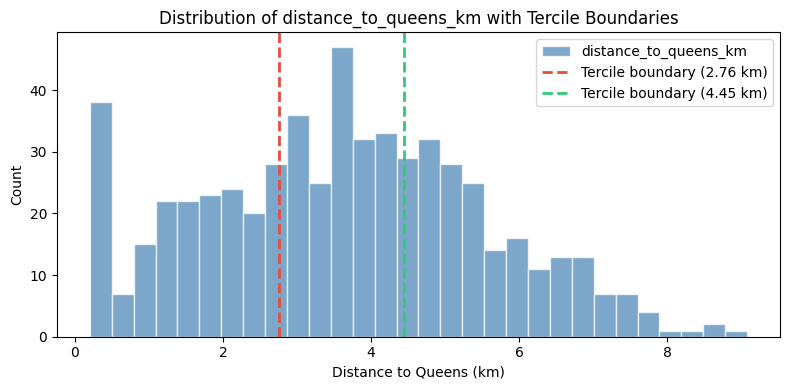

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X['distance_to_queens_km'], bins=30, edgecolor='white', alpha=0.7,
        color='steelblue', label='distance_to_queens_km')

colours = ['#e74c3c', '#2ecc71']
for i, edge in enumerate(DIST_BINS[1:-1]):
    ax.axvline(edge, color=colours[i], ls='--', lw=2,
               label=f'Tercile boundary ({edge:.2f} km)')

ax.set_xlabel('Distance to Queens (km)')
ax.set_ylabel('Count')
ax.set_title('Distribution of distance_to_queens_km with Tercile Boundaries')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Train Models 3 and 4

### Model 3 — Distance band only

Cyclical month encoding (same as baseline) **+ `distance_band`** as a
new categorical feature.

We try both *keeping* and *dropping* the raw `distance_to_queens_km`
column and pick whichever performs better (higher mean metric).

In [12]:
# --- Model 3a: cyclical month + distance_band (KEEP raw distance) ---
X_train_3a = add_distance_band(add_cyclical_month(X_train), drop_raw=False)
X_test_3a  = add_distance_band(add_cyclical_month(X_test),  drop_raw=False)

CAT_FEATURES_3a = CAT_FEATURES_BASELINE + ['distance_band']

model_3a = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_3a.fit(X_train_3a, y_train, cat_features=CAT_FEATURES_3a,
             eval_set=(X_test_3a, y_test), early_stopping_rounds=50)

metrics_3a = evaluate_model('Dist-band (keep raw)', model_3a, X_test_3a, y_test, CAT_FEATURES_3a)

# --- Model 3b: cyclical month + distance_band (DROP raw distance) ---
X_train_3b = add_distance_band(add_cyclical_month(X_train), drop_raw=True)
X_test_3b  = add_distance_band(add_cyclical_month(X_test),  drop_raw=True)

CAT_FEATURES_3b = CAT_FEATURES_BASELINE + ['distance_band']

model_3b = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_3b.fit(X_train_3b, y_train, cat_features=CAT_FEATURES_3b,
             eval_set=(X_test_3b, y_test), early_stopping_rounds=50)

metrics_3b = evaluate_model('Dist-band (drop raw)', model_3b, X_test_3b, y_test, CAT_FEATURES_3b)

# --- Pick the better variant ---
def _mean_metric(m):
    return np.mean([v for k, v in m.items() if k != 'Model'])

keep_raw_dist_m3 = _mean_metric(metrics_3a) >= _mean_metric(metrics_3b)

if keep_raw_dist_m3:
    dist_metrics = metrics_3a
    dist_metrics['Model'] = 'Dist-band only'
    model_dist = model_3a
    CAT_FEATURES_DIST = CAT_FEATURES_3a
    DROP_RAW_DIST_M3 = False
else:
    dist_metrics = metrics_3b
    dist_metrics['Model'] = 'Dist-band only'
    model_dist = model_3b
    CAT_FEATURES_DIST = CAT_FEATURES_3b
    DROP_RAW_DIST_M3 = True

print(f'Model 3a (keep raw) mean metric: {_mean_metric(metrics_3a):.4f}')
print(f'Model 3b (drop raw) mean metric: {_mean_metric(metrics_3b):.4f}')
print(f'→ Selected: {"keep" if not DROP_RAW_DIST_M3 else "drop"} raw distance_to_queens_km')
print()
print('Model 3 (Dist-band only) metrics:')
for k, v in dist_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Model 3a (keep raw) mean metric: 0.8525
Model 3b (drop raw) mean metric: 0.8364
→ Selected: keep raw distance_to_queens_km

Model 3 (Dist-band only) metrics:
  Accuracy             0.7241
  NDCG                 0.9694
  ROC AUC (OvR)        0.8505
  Top-2 Accuracy       0.9828
  Recall (macro)       0.7357


### Model 4 — Season + Distance band

Both feature engineering changes combined:
season categorical **+ `distance_band`**.

Same keep-vs-drop test for the raw distance column.

In [13]:
# --- Model 4a: season + distance_band (KEEP raw distance) ---
X_train_4a = add_distance_band(add_season(X_train), drop_raw=False)
X_test_4a  = add_distance_band(add_season(X_test),  drop_raw=False)

CAT_FEATURES_4a = CAT_FEATURES_OPTIMISED + ['distance_band']

model_4a = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_4a.fit(X_train_4a, y_train, cat_features=CAT_FEATURES_4a,
             eval_set=(X_test_4a, y_test), early_stopping_rounds=50)

metrics_4a = evaluate_model('Season+Dist (keep raw)', model_4a, X_test_4a, y_test, CAT_FEATURES_4a)

# --- Model 4b: season + distance_band (DROP raw distance) ---
X_train_4b = add_distance_band(add_season(X_train), drop_raw=True)
X_test_4b  = add_distance_band(add_season(X_test),  drop_raw=True)

CAT_FEATURES_4b = CAT_FEATURES_OPTIMISED + ['distance_band']

model_4b = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_4b.fit(X_train_4b, y_train, cat_features=CAT_FEATURES_4b,
             eval_set=(X_test_4b, y_test), early_stopping_rounds=50)

metrics_4b = evaluate_model('Season+Dist (drop raw)', model_4b, X_test_4b, y_test, CAT_FEATURES_4b)

# --- Pick the better variant ---
keep_raw_dist_m4 = _mean_metric(metrics_4a) >= _mean_metric(metrics_4b)

if keep_raw_dist_m4:
    both_metrics = metrics_4a
    both_metrics['Model'] = 'Season + Dist-band'
    model_both = model_4a
    CAT_FEATURES_BOTH = CAT_FEATURES_4a
    DROP_RAW_DIST_M4 = False
else:
    both_metrics = metrics_4b
    both_metrics['Model'] = 'Season + Dist-band'
    model_both = model_4b
    CAT_FEATURES_BOTH = CAT_FEATURES_4b
    DROP_RAW_DIST_M4 = True

print(f'Model 4a (keep raw) mean metric: {_mean_metric(metrics_4a):.4f}')
print(f'Model 4b (drop raw) mean metric: {_mean_metric(metrics_4b):.4f}')
print(f'→ Selected: {"keep" if not DROP_RAW_DIST_M4 else "drop"} raw distance_to_queens_km')
print()
print('Model 4 (Season + Dist-band) metrics:')
for k, v in both_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Model 4a (keep raw) mean metric: 0.8408
Model 4b (drop raw) mean metric: 0.8583
→ Selected: drop raw distance_to_queens_km

Model 4 (Season + Dist-band) metrics:
  Accuracy             0.7414
  NDCG                 0.9665
  ROC AUC (OvR)        0.8449
  Top-2 Accuracy       0.9828
  Recall (macro)       0.7559


### Raw Distance Decision

The cells above compared keeping vs dropping `distance_to_queens_km`
alongside the new `distance_band` categorical. The chosen variant for
each model is printed in the output above.

## 9. Full Ablation Comparison

All four models side-by-side, plus delta rows showing the improvement
(or regression) of each variant relative to the baseline.

In [14]:
# Rename baseline / optimised to shorter labels for consistency
baseline_metrics_row  = {**baseline_metrics,  'Model': 'Baseline (cyclical)'}
season_metrics_row    = {**optimised_metrics,  'Model': 'Season only'}
dist_metrics_row      = {**dist_metrics,       'Model': 'Dist-band only'}
both_metrics_row      = {**both_metrics,       'Model': 'Season + Dist-band'}

all_rows = [baseline_metrics_row, season_metrics_row, dist_metrics_row, both_metrics_row]
ablation = pd.DataFrame(all_rows).set_index('Model')

# Delta rows
metric_cols = ablation.columns.tolist()
for lbl in ['Season only', 'Dist-band only', 'Season + Dist-band']:
    delta = ablation.loc[lbl] - ablation.loc['Baseline (cyclical)']
    delta.name = f'Δ {lbl}'
    ablation = pd.concat([ablation, delta.to_frame().T])

# Pretty-print
print('=' * 90)
print('  FULL ABLATION — 4 CatBoost Variants')
print('=' * 90)

display_ab = ablation.copy()
for col in display_ab.columns:
    display_ab[col] = display_ab[col].apply(
        lambda x: f'{x:+.4f}' if x < 0 else f'{x:.4f}'
    )

print(display_ab.to_string())
print('=' * 90)

  FULL ABLATION — 4 CatBoost Variants
                     Accuracy     NDCG ROC AUC (OvR) Top-2 Accuracy Recall (macro)
Baseline (cyclical)    0.7241   0.9668        0.8308         0.9655         0.7323
Season only            0.6983   0.9859        0.8601         0.9914         0.6995
Dist-band only         0.7241   0.9694        0.8505         0.9828         0.7357
Season + Dist-band     0.7414   0.9665        0.8449         0.9828         0.7559
Δ Season only         -0.0259   0.0192        0.0293         0.0259        -0.0328
Δ Dist-band only       0.0000   0.0026        0.0197         0.0172         0.0034
Δ Season + Dist-band   0.0172  -0.0003        0.0141         0.0172         0.0236


Saved figures/22_ablation_heatmap.png


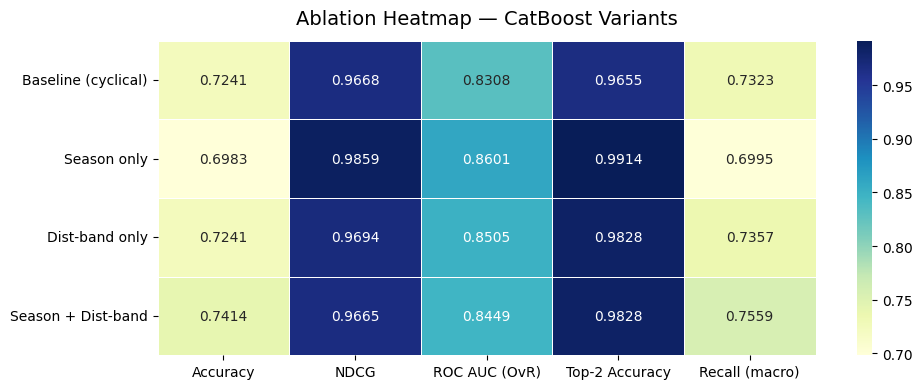

In [15]:
# ── Heatmap (4 models × 5 metrics) ─────────────────────────
model_labels = ['Baseline (cyclical)', 'Season only', 'Dist-band only', 'Season + Dist-band']
heat_data = ablation.loc[model_labels]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heat_data.astype(float), annot=True, fmt='.4f', cmap='YlGnBu',
    linewidths=0.5, ax=ax,
)
ax.set_title('Ablation Heatmap — CatBoost Variants', fontsize=14, pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()

Path('figures').mkdir(exist_ok=True)
fig.savefig('figures/22_ablation_heatmap.png', dpi=150)
print('Saved figures/22_ablation_heatmap.png')
plt.show()

Saved figures/23_ablation_bar_chart.png


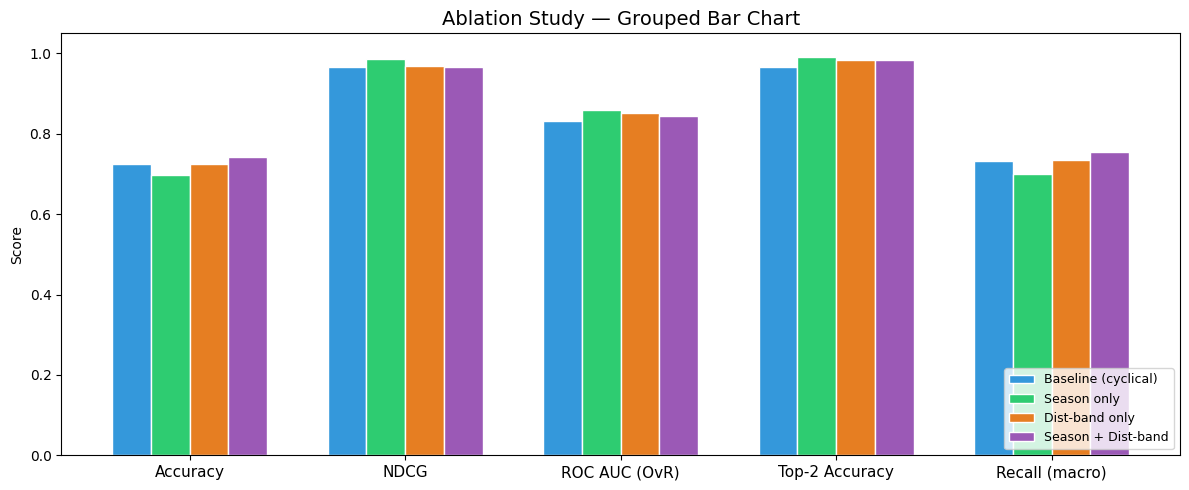

In [16]:
# ── Grouped Bar Chart ──────────────────────────────────────
bar_data = ablation.loc[model_labels].astype(float)
n_metrics = len(metric_cols)
n_models  = len(model_labels)
x = np.arange(n_metrics)
width = 0.18

colours = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, colour) in enumerate(zip(model_labels, colours)):
    vals = bar_data.loc[model].values
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=model, color=colour, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Ablation Study — Grouped Bar Chart', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout()

fig.savefig('figures/23_ablation_bar_chart.png', dpi=150)
print('Saved figures/23_ablation_bar_chart.png')
plt.show()

## 10. Ablation Takeaways

### Which individual feature helped most?

Compare the **Δ rows** in the table above:

- **Season only** replaces cyclical month encoding with a single
  business-meaningful categorical. Any positive delta here confirms
  that CatBoost's native categorical handling outperforms
  trigonometric floats for this seasonal business.
- **Distance band only** adds a discretised proximity feature while
  keeping cyclical month encoding. Positive deltas indicate that
  distance-based segmentation carries useful signal beyond the raw
  numeric value.

### Is the combination better than either alone?

Check the **Season + Dist-band** row against the two individual
variants. If it leads on most metrics, the features capture
complementary signals (seasonality vs geography). If it matches or
underperforms, the two features may be redundant or the additional
complexity is not justified.

### Current best model

The model with the highest values across the majority of the five
metrics (especially **NDCG** and **ROC AUC**, which are most relevant
for lead-ranking) should be promoted as the current best. Refer to
the heatmap and bar chart for a visual summary.

> **Action item:** Once the best variant is confirmed, retrain it on
> the *full* labelled set and generate updated predictions for the
> unlabelled leads.

## 11. Weather Binary Feature Engineering

Collapse `lead_capture_weather` into two categories — **Good** and
**Bad** — and pass the result as a CatBoost categorical.

### Rationale

Weather at the time of lead capture likely correlates with seasonal
demand patterns and customer urgency. However, the original column
has five granular categories, several of which have relatively few
samples. Collapsing to binary:

1. **Reduces noise** — categories with <100 samples (e.g. Snow) may
   not give CatBoost enough data to learn reliable splits.
2. **Captures the core signal** — the decision-relevant distinction
   is whether conditions were favourable for outdoor painting work,
   not the exact weather type.
3. **Simplifies interpretation** — stakeholders understand
   "good weather vs bad weather" more readily than five categories.

In [17]:
# Current unique values and counts
print('lead_capture_weather — unique values and counts:')
print(X_train['lead_capture_weather'].value_counts().sort_index())
print(f'\nTest set:')
print(X_test['lead_capture_weather'].value_counts().sort_index())

lead_capture_weather — unique values and counts:
lead_capture_weather
Cloudy    121
Rain       88
Snow       39
Sunny     163
Windy      49
Name: count, dtype: int64

Test set:
lead_capture_weather
Cloudy    34
Rain      21
Snow      10
Sunny     36
Windy     15
Name: count, dtype: int64


### Weather Mapping

| Original Value | Binary | Reasoning |
|---|---|---|
| Sunny | Good | Clear, favourable for outdoor work |
| Cloudy | Bad | Overcast, less likely to start outdoor projects |
| Rain | Bad | Wet conditions, outdoor work unlikely |
| Snow | Bad | Cold/wet, outdoor painting not viable |
| Windy | Bad | Wind disrupts painting and drying |

In [18]:
WEATHER_MAP = {
    'Sunny':  'Good',
    'Cloudy': 'Bad',
    'Rain':   'Bad',
    'Snow':   'Bad',
    'Windy':  'Bad',
}


def add_weather_binary(df: pd.DataFrame) -> pd.DataFrame:
    """Replace `lead_capture_weather` with a binary `weather_binary` column."""
    df = df.copy()
    df['weather_binary'] = df['lead_capture_weather'].map(WEATHER_MAP)
    df = df.drop(columns=['lead_capture_weather'])
    return df


# Show distribution
_tmp_w = add_weather_binary(X)
print('weather_binary distribution (full labelled set):')
print(_tmp_w['weather_binary'].value_counts().sort_index())

weather_binary distribution (full labelled set):
weather_binary
Bad     377
Good    199
Name: count, dtype: int64


## 12. Train Models 5–8 (Weather Binary Combinations)

Four new models that each include the `weather_binary` feature,
combined with one or both of the other engineered features.

| # | Model | Season? | Dist-band? | Weather binary? |
|---|---|---|---|---|
| 5 | Season + Weather | ✓ | | ✓ |
| 6 | Dist-band + Weather | | ✓ | ✓ |
| 7 | Weather only | | | ✓ |
| 8 | Season + Dist + Weather | ✓ | ✓ | ✓ |

In [19]:
def _swap_weather_in_cats(cat_list: list[str]) -> list[str]:
    """Replace 'lead_capture_weather' with 'weather_binary' in a cat-feature list."""
    return [
        'weather_binary' if c == 'lead_capture_weather' else c
        for c in cat_list
    ]

### Model 7 — Weather binary only

Cyclical month + raw distance + weather collapsed to binary.
Same as baseline but with `weather_binary` instead of
`lead_capture_weather`.

In [20]:
X_train_7 = add_weather_binary(add_cyclical_month(X_train))
X_test_7  = add_weather_binary(add_cyclical_month(X_test))

CAT_FEATURES_7 = _swap_weather_in_cats(CAT_FEATURES_BASELINE)

model_7 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_7.fit(X_train_7, y_train, cat_features=CAT_FEATURES_7,
            eval_set=(X_test_7, y_test), early_stopping_rounds=50)

weather_only_metrics = evaluate_model(
    'Weather only', model_7, X_test_7, y_test, CAT_FEATURES_7,
)

print('Model 7 (Weather only) metrics:')
for k, v in weather_only_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Model 7 (Weather only) metrics:
  Accuracy             0.6810
  NDCG                 0.9796
  ROC AUC (OvR)        0.8610
  Top-2 Accuracy       0.9741
  Recall (macro)       0.6860


### Model 5 — Season + Weather binary

Season replaces cyclical month, weather collapsed, raw distance kept.

In [21]:
X_train_5 = add_weather_binary(add_season(X_train))
X_test_5  = add_weather_binary(add_season(X_test))

CAT_FEATURES_5 = _swap_weather_in_cats(CAT_FEATURES_OPTIMISED)

model_5 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_5.fit(X_train_5, y_train, cat_features=CAT_FEATURES_5,
            eval_set=(X_test_5, y_test), early_stopping_rounds=50)

season_weather_metrics = evaluate_model(
    'Season + Weather', model_5, X_test_5, y_test, CAT_FEATURES_5,
)

print('Model 5 (Season + Weather) metrics:')
for k, v in season_weather_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Model 5 (Season + Weather) metrics:
  Accuracy             0.7155
  NDCG                 0.9793
  ROC AUC (OvR)        0.8600
  Top-2 Accuracy       0.9828
  Recall (macro)       0.7231


### Model 6 — Dist-band + Weather binary

Cyclical month + distance band + weather collapsed.
Uses the same `drop_raw` decision from Model 3.

In [22]:
X_train_6 = add_weather_binary(add_distance_band(add_cyclical_month(X_train), drop_raw=DROP_RAW_DIST_M3))
X_test_6  = add_weather_binary(add_distance_band(add_cyclical_month(X_test),  drop_raw=DROP_RAW_DIST_M3))

CAT_FEATURES_6 = _swap_weather_in_cats(CAT_FEATURES_DIST)

model_6 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_6.fit(X_train_6, y_train, cat_features=CAT_FEATURES_6,
            eval_set=(X_test_6, y_test), early_stopping_rounds=50)

dist_weather_metrics = evaluate_model(
    'Dist + Weather', model_6, X_test_6, y_test, CAT_FEATURES_6,
)

print('Model 6 (Dist-band + Weather) metrics:')
for k, v in dist_weather_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Model 6 (Dist-band + Weather) metrics:
  Accuracy             0.7155
  NDCG                 0.9721
  ROC AUC (OvR)        0.8506
  Top-2 Accuracy       0.9914
  Recall (macro)       0.7247


### Model 8 — Season + Dist-band + Weather binary

All three feature engineering changes combined.
Uses the same `drop_raw` decision from Model 4.

In [23]:
X_train_8 = add_weather_binary(add_distance_band(add_season(X_train), drop_raw=DROP_RAW_DIST_M4))
X_test_8  = add_weather_binary(add_distance_band(add_season(X_test),  drop_raw=DROP_RAW_DIST_M4))

CAT_FEATURES_8 = _swap_weather_in_cats(CAT_FEATURES_BOTH)

model_8 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, eval_metric='Accuracy', verbose=0,
)
model_8.fit(X_train_8, y_train, cat_features=CAT_FEATURES_8,
            eval_set=(X_test_8, y_test), early_stopping_rounds=50)

all_three_metrics = evaluate_model(
    'Season + Dist + Weather', model_8, X_test_8, y_test, CAT_FEATURES_8,
)

print('Model 8 (Season + Dist + Weather) metrics:')
for k, v in all_three_metrics.items():
    if k != 'Model':
        print(f'  {k:20s} {v:.4f}')

Model 8 (Season + Dist + Weather) metrics:
  Accuracy             0.7241
  NDCG                 0.9698
  ROC AUC (OvR)        0.8622
  Top-2 Accuracy       0.9828
  Recall (macro)       0.7340


## 13. Full 8-Model Ablation Comparison

All eight CatBoost variants side-by-side, with delta rows showing
the change relative to the baseline for each model.

In [24]:
# Collect all 8 model metric rows
all_8_rows = [
    {**baseline_metrics,        'Model': '1. Baseline'},
    {**optimised_metrics,        'Model': '2. Season'},
    {**dist_metrics,             'Model': '3. Dist-band'},
    {**weather_only_metrics,     'Model': '4. Weather'},
    {**both_metrics,             'Model': '5. Season+Dist'},
    {**season_weather_metrics,   'Model': '6. Season+Weather'},
    {**dist_weather_metrics,     'Model': '7. Dist+Weather'},
    {**all_three_metrics,        'Model': '8. All Three'},
]

full_ablation = pd.DataFrame(all_8_rows).set_index('Model')
metric_cols_8 = full_ablation.columns.tolist()

# Add delta rows
baseline_row = full_ablation.loc['1. Baseline']
for lbl in full_ablation.index:
    if lbl == '1. Baseline':
        continue
    delta = full_ablation.loc[lbl] - baseline_row
    delta.name = f'Δ {lbl}'
    full_ablation = pd.concat([full_ablation, delta.to_frame().T])

# Pretty-print
print('=' * 100)
print('  FULL 8-MODEL ABLATION')
print('=' * 100)

disp = full_ablation.copy()
for col in disp.columns:
    disp[col] = disp[col].apply(lambda x: f'{x:+.4f}' if x < 0 else f'{x:.4f}')

print(disp.to_string())
print('=' * 100)

  FULL 8-MODEL ABLATION
                    Accuracy     NDCG ROC AUC (OvR) Top-2 Accuracy Recall (macro)
1. Baseline           0.7241   0.9668        0.8308         0.9655         0.7323
2. Season             0.6983   0.9859        0.8601         0.9914         0.6995
3. Dist-band          0.7241   0.9694        0.8505         0.9828         0.7357
4. Weather            0.6810   0.9796        0.8610         0.9741         0.6860
5. Season+Dist        0.7414   0.9665        0.8449         0.9828         0.7559
6. Season+Weather     0.7155   0.9793        0.8600         0.9828         0.7231
7. Dist+Weather       0.7155   0.9721        0.8506         0.9914         0.7247
8. All Three          0.7241   0.9698        0.8622         0.9828         0.7340
Δ 2. Season          -0.0259   0.0192        0.0293         0.0259        -0.0328
Δ 3. Dist-band        0.0000   0.0026        0.0197         0.0172         0.0034
Δ 4. Weather         -0.0431   0.0128        0.0302         0.0086        

Saved figures/24_ablation_8model_heatmap.png


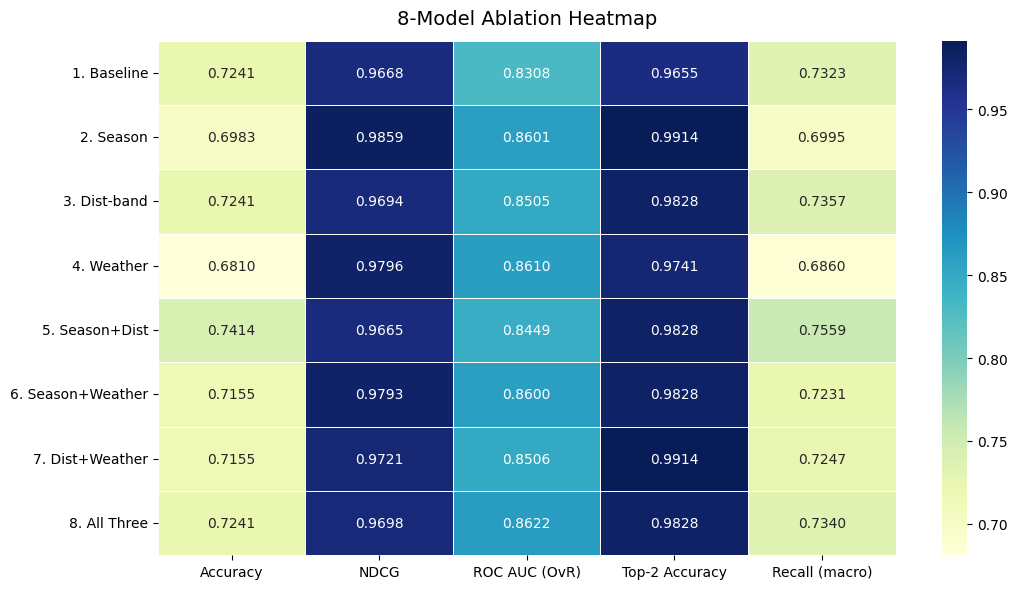

In [25]:
# ── Heatmap (8 models × 5 metrics) ─────────────────────────
model_8_labels = [
    '1. Baseline', '2. Season', '3. Dist-band', '4. Weather',
    '5. Season+Dist', '6. Season+Weather', '7. Dist+Weather', '8. All Three',
]
heat_8 = full_ablation.loc[model_8_labels].astype(float)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    heat_8, annot=True, fmt='.4f', cmap='YlGnBu',
    linewidths=0.5, ax=ax,
)
ax.set_title('8-Model Ablation Heatmap', fontsize=14, pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()

fig.savefig('figures/24_ablation_8model_heatmap.png', dpi=150)
print('Saved figures/24_ablation_8model_heatmap.png')
plt.show()

Saved figures/25_ablation_8model_bar_chart.png


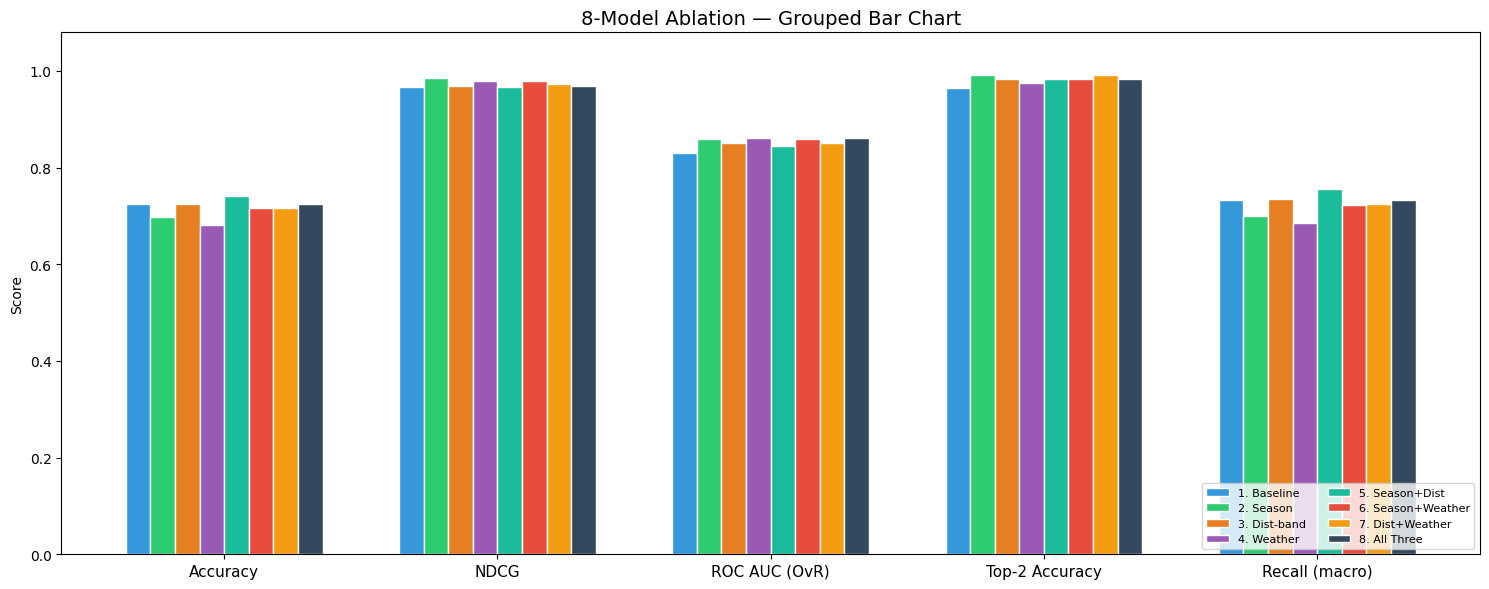

In [26]:
# ── Grouped Bar Chart (8 bars per metric) ─────────────────
bar_8 = full_ablation.loc[model_8_labels].astype(float)
n_met  = len(metric_cols_8)
n_mod  = len(model_8_labels)
x = np.arange(n_met)
width = 0.09

colours_8 = [
    '#3498db', '#2ecc71', '#e67e22', '#9b59b6',
    '#1abc9c', '#e74c3c', '#f39c12', '#34495e',
]

fig, ax = plt.subplots(figsize=(15, 6))
for i, (model, colour) in enumerate(zip(model_8_labels, colours_8)):
    vals = bar_8.loc[model].values
    offset = (i - n_mod / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=model, color=colour, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols_8, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('8-Model Ablation — Grouped Bar Chart', fontsize=14)
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.set_ylim(0, 1.08)
plt.tight_layout()

fig.savefig('figures/25_ablation_8model_bar_chart.png', dpi=150)
print('Saved figures/25_ablation_8model_bar_chart.png')
plt.show()

In [27]:
# ── Rank Table (1 = best for each metric) ─────────────────
rank_data = full_ablation.loc[model_8_labels].astype(float)
rank_table = rank_data.rank(ascending=False, method='min').astype(int)

print('Model Rankings (1 = best):')
print(rank_table.to_string())

# Average rank
rank_table['Avg Rank'] = rank_table.mean(axis=1).round(2)
rank_table = rank_table.sort_values('Avg Rank')

print('\nSorted by Average Rank:')
print(rank_table.to_string())

Model Rankings (1 = best):
                   Accuracy  NDCG  ROC AUC (OvR)  Top-2 Accuracy  Recall (macro)
1. Baseline               2     7              8               8               4
2. Season                 7     1              3               1               7
3. Dist-band              2     6              6               3               2
4. Weather                8     2              2               7               8
5. Season+Dist            1     8              7               3               1
6. Season+Weather         5     3              4               3               6
7. Dist+Weather           5     4              5               1               5
8. All Three              2     5              1               3               3

Sorted by Average Rank:
                   Accuracy  NDCG  ROC AUC (OvR)  Top-2 Accuracy  Recall (macro)  Avg Rank
8. All Three              2     5              1               3               3       2.8
2. Season                 7     1    

## 14. Ablation Takeaways

### Does weather binary help on its own?

Compare **Model 4 (Weather only)** against the **Baseline**. If most
delta values are positive, the binary weather encoding captures useful
signal that the finer-grained original categories missed (due to small
sample sizes per category).

### Does it improve existing combinations?

Compare each pair:

| Without Weather | With Weather | Better? |
|---|---|---|
| 2. Season | 6. Season+Weather | Check deltas |
| 3. Dist-band | 7. Dist+Weather | Check deltas |
| 5. Season+Dist | 8. All Three | Check deltas |

If adding weather consistently improves metrics, it carries
complementary signal.

### Feature interaction evidence

If two features together produce a bigger improvement than the **sum**
of their individual improvements, there is evidence of positive
interaction — the features capture complementary information that the
model can exploit jointly. Check this for all three pairwise
combinations and the triple.

### Current best model

Refer to the **rank table** and **average rank** above. The model with
the lowest average rank across all five metrics is the recommended
choice. In case of ties, prefer the model that leads on **NDCG** and
**ROC AUC** (the two most relevant metrics for lead-ranking).

### Recommendation

Promote the best-ranked model as the current production candidate.
Retrain it on the **full** labelled set and generate updated
predictions for the unlabelled leads.

> **Next step:** Depending on the rank table results, either adopt the
> top model or investigate whether metric improvements are
> statistically significant via cross-validation.